# Detecção de Fraude em Transações de Cartão de Crédito

## 1. Compreensão do problema

Instituições financeiras processam milhões de transações de cartão de crédito diariamente, e apenas uma fração ínfima delas corresponde a fraudes. Esse cenário caracteriza um problema clássico de classificação com forte desbalanceamento de classes, no qual a classe de interesse (fraude) é extremamente rara em comparação com a classe majoritária (transações legítimas).

O objetivo deste projeto é desenvolver um modelo de classificação capaz de identificar transações fraudulentas com base em variáveis numéricas derivadas das características da transação, minimizando dois tipos de erro que possuem custos de negócio bem distintos:

- **Falso negativo** (uma fraude classificada como legítima): representa prejuízo financeiro direto para a instituição e para o cliente lesado, além de risco reputacional.
- **Falso positivo** (uma transação legítima classificada como fraude): representa custo operacional (acionamento desnecessário da equipe de prevenção a fraudes) e impacto negativo na experiência do cliente, que pode ter o cartão bloqueado indevidamente.

Como o dataset contém variáveis já transformadas por PCA (V1 a V28), por motivos de confidencialidade dos dados originais, a análise não pode se apoiar na interpretação direta do significado de cada variável, mas sim em seu comportamento estatístico e em sua relação com a variável alvo.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score,
                              average_precision_score, precision_recall_curve, roc_curve)
from imblearn.over_sampling import SMOTE

## 2. Exploração e preparação dos dados



In [2]:
df = pd.read_csv("Base_M43_Pratique_CREDIT_CARD_FRAUD.csv")

df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,-0.371407,1.341262,0.359894,-0.358091,-0.137134,0.517617,0.401726,-0.058133,0.068653,-0.033194,0.084968,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,-0.099254,-1.416907,-0.153826,-0.751063,0.167372,0.050144,-0.443587,0.002821,-0.611987,-0.045575,-0.219633,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,1.249376,-0.619468,0.291474,1.757964,-1.323865,0.686133,-0.076127,-1.222127,-0.358222,0.324505,-0.156742,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,-0.410430,-0.705117,-0.110452,-0.286254,0.074355,-0.328783,-0.210077,-0.499768,0.118765,0.570328,0.052736,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,-0.366846,1.017614,0.836390,1.006844,-0.443523,0.150219,0.739453,-0.540980,0.476677,0.451773,0.203711,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [ ]:
# Verificação de dimensão, tipos de dados e valores faltantes

print("Dimensão da base:", df.shape)
print()
print("Tipos de dados:")
print(df.dtypes.value_counts())
print()
print("Total de valores faltantes na base:", df.isnull().sum().sum())

Dimensão da base: (284807, 31)

Tipos de dados:
float64    30
int64       1
Name: count, dtype: int64

Total de valores faltantes na base: 0


A base possui aproximadamente 285 mil transações e 31 colunas, todas numéricas. Não há nenhum valor faltante em nenhuma coluna, o que é um ponto positivo, já que elimina a necessidade de imputação de dados nesta etapa.



In [ ]:
# Verificação de linhas duplicadas

print("Quantidade de linhas duplicadas:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Dimensão da base após a remoção de duplicatas:", df.shape)

Quantidade de linhas duplicadas: 1081
Dimensão da base após a remoção de duplicatas: (283726, 31)


Foram encontradas mais de mil linhas duplicadas, o que, em um contexto de detecção de fraude, poderia inflar artificialmente a importância de determinados padrões durante o treinamento do modelo. Por esse motivo, as duplicatas foram removidas antes de qualquer análise ou modelagem.



In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,-0.001441,0.000202,-0.000715,0.000603,0.000252,0.001043,0.001162,0.000170,0.001515,-0.000264,0.000187,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,1.076407,1.018720,0.994674,0.995430,0.952215,0.914894,0.873696,0.842507,0.837378,0.813379,0.769984,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,-24.588262,-4.797473,-18.683715,-5.791881,-19.214325,-4.498945,-14.129855,-25.162799,-9.498746,-7.213527,-54.497720,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,-0.535578,-0.761649,-0.406198,-0.647862,-0.425732,-0.581452,-0.466860,-0.483928,-0.498014,-0.456289,-0.211469,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,-0.093237,-0.032306,0.139072,-0.012927,0.050209,0.049299,0.067119,-0.065867,-0.002142,0.003367,-0.062353,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,0.453619,0.739579,0.616976,0.663178,0.492336,0.650104,0.523512,0.398972,0.501956,0.458508,0.133207,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,23.745136,12.018913,7.848392,7.126883,10.526766,8.877742,17.315112,9.253526,5.041069,5.591971,39.420904,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


As variáveis V1 a V28 já foram transformadas por PCA e apresentam médias próximas de zero, sugerindo que já estão em uma escala relativamente padronizada. Já as variáveis Time (tempo em segundos desde a primeira transação da base) e Amount (valor da transação) estão em escalas bem diferentes das demais, e precisarão ser padronizadas antes da modelagem.



## 3. Análise do desbalanceamento de classes



In [6]:
contagem_classes = df['Class'].value_counts()
percentual_classes = df['Class'].value_counts(normalize=True) * 100

print("Contagem de classes:")
print(contagem_classes)
print()
print("Percentual de cada classe:")
print(percentual_classes)

Contagem de classes:
Class
0    283253
1       473
Name: count, dtype: int64

Percentual de cada classe:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


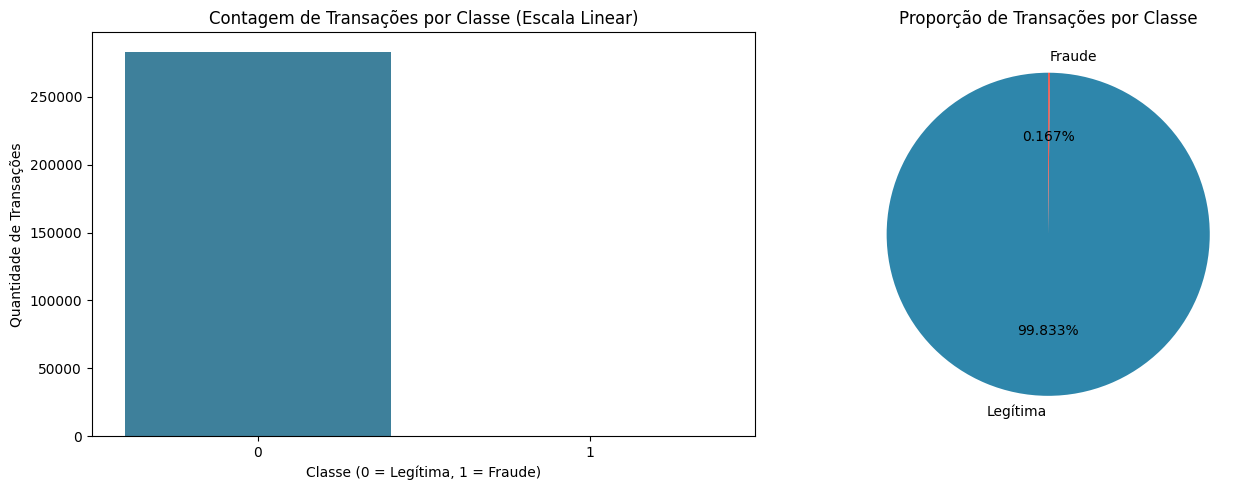

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Class', color='#2E86AB', ax=axes[0])
axes[0].set_title('Contagem de Transações por Classe (Escala Linear)')
axes[0].set_xlabel('Classe (0 = Legítima, 1 = Fraude)')
axes[0].set_ylabel('Quantidade de Transações')

axes[1].pie(contagem_classes, labels=['Legítima', 'Fraude'], autopct='%1.3f%%',
            colors=['#2E86AB', '#F24236'], startangle=90)
axes[1].set_title('Proporção de Transações por Classe')

plt.tight_layout()
plt.show()

O desbalanceamento é extremo: apenas cerca de 0,17% das transações da base correspondem a fraudes. Esse é o principal desafio técnico do projeto, já que um modelo que simplesmente classificasse todas as transações como legítimas atingiria mais de 99,8% de acurácia, sem detectar nenhuma fraude. Por esse motivo, a acurácia não será utilizada como métrica principal de avaliação neste projeto, dando lugar a métricas mais adequadas para classes desbalanceadas, como precisão, recall, F1-score e a área sob a curva de precisão-recall (PR-AUC).



## 4. Análise exploratória



In [ ]:
# Correlação de cada variável com a variável alvo, ordenada pela força da relação

correlacao_class = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)

correlacao_class.head(10)

V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
V3    -0.182322
V7    -0.172347
V11    0.149067
V4     0.129326
V18   -0.105340
Name: Class, dtype: float64

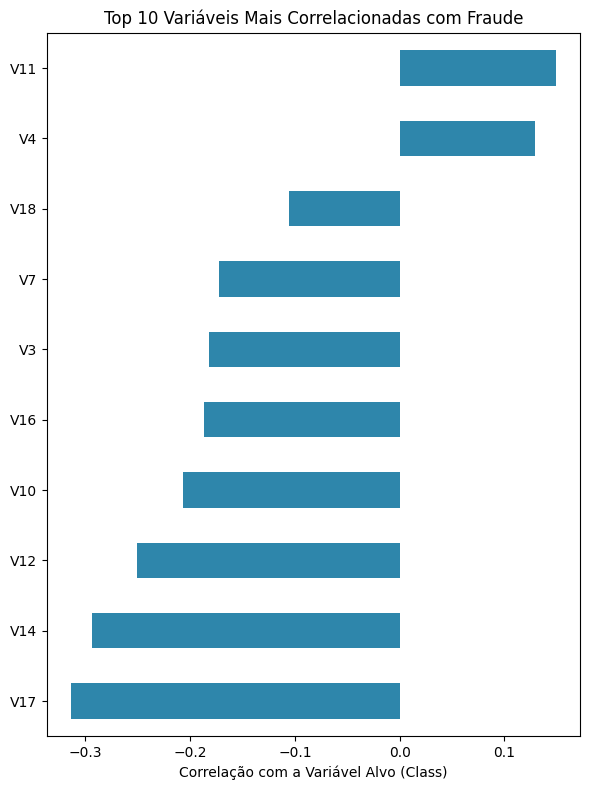

In [9]:
plt.figure(figsize=(6, 8))
correlacao_class.head(10).sort_values().plot(kind='barh', color='#2E86AB')
plt.title('Top 10 Variáveis Mais Correlacionadas com Fraude')
plt.xlabel('Correlação com a Variável Alvo (Class)')
plt.tight_layout()
plt.show()

As variáveis V17, V14, V12 e V10 apresentam as correlações mais fortes (negativas) com a ocorrência de fraude, seguidas por V16, V3, V7 e V11. Mesmo sem saber o significado original dessas variáveis (ocultado pela transformação PCA), essa análise já indica quais delas concentram o maior poder discriminante entre transações legítimas e fraudulentas, e serão especialmente observadas na análise bivariada a seguir.



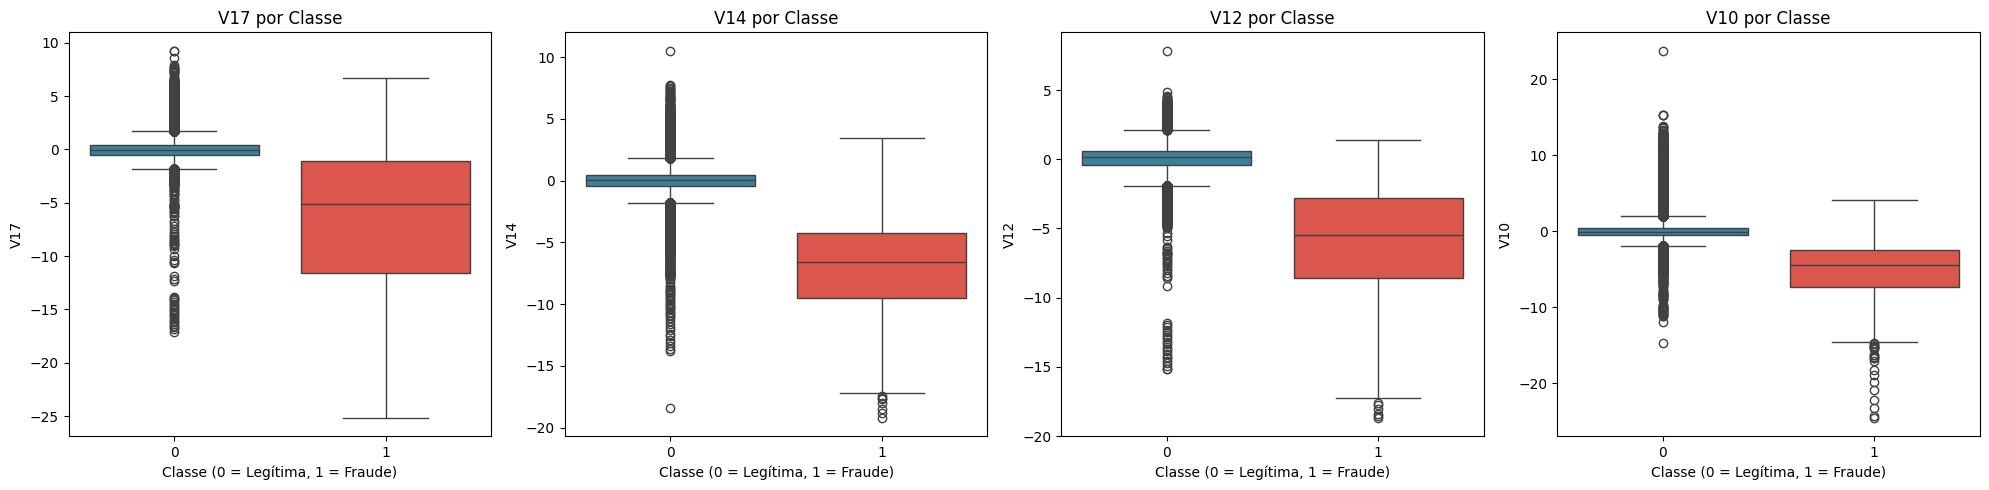

In [ ]:
# Comparação da distribuição das 4 variáveis mais correlacionadas, separando por classe

top4_variaveis = correlacao_class.head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, coluna in enumerate(top4_variaveis):
    sns.boxplot(data=df, x='Class', y=coluna, ax=axes[i], palette=['#2E86AB', '#F24236'])
    axes[i].set_title(f'{coluna} por Classe')
    axes[i].set_xlabel('Classe (0 = Legítima, 1 = Fraude)')

plt.tight_layout()
plt.show()

Os boxplots confirmam visualmente o que a correlação já indicava: para essas quatro variáveis, a distribuição de valores das transações fraudulentas é claramente deslocada em relação às transações legítimas, com pouca sobreposição entre as caixas. Isso é um bom sinal para a modelagem, já que sugere que existe, sim, um padrão estatístico capturável pelos algoritmos de classificação.



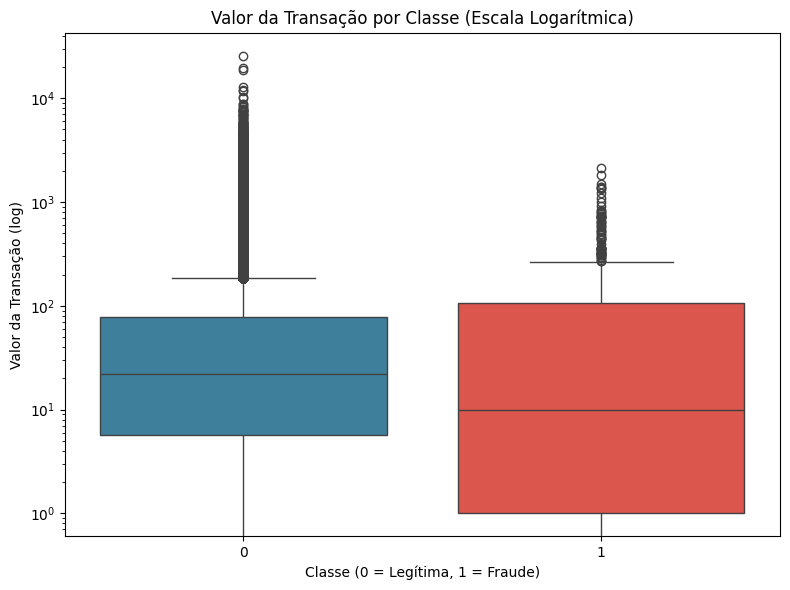

In [ ]:
# Distribuição do valor da transação (Amount) por classe, em escala logarítmica
# (o valor bruto tem uma cauda muito longa, dificultando a visualização em escala linear)

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Class', y='Amount', palette=['#2E86AB', '#F24236'])
plt.yscale('log')
plt.title('Valor da Transação por Classe (Escala Logarítmica)')
plt.xlabel('Classe (0 = Legítima, 1 = Fraude)')
plt.ylabel('Valor da Transação (log)')
plt.tight_layout()
plt.show()

Ao contrário do que a intuição poderia sugerir, as transações fraudulentas não apresentam, de forma consistente, valores muito mais altos do que as legítimas; a mediana de valor das fraudes é, na verdade, um pouco mais baixa. Isso indica que fraudadores não necessariamente buscam transações de alto valor, possivelmente para evitar sistemas de alerta automático que costumam monitorar valores elevados com mais atenção.



## 5. Pré-processamento para a modelagem



In [ ]:
# Padronização das variáveis Amount e Time, que ainda não estavam na mesma escala das demais

scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_Scaled'] = scaler.fit_transform(df[['Time']])

df = df.drop(columns=['Amount', 'Time'])

df[['Amount_Scaled', 'Time_Scaled']].describe()

,Amount_Scaled,Time_Scaled
count,2.837260e+05,2.837260e+05
mean,-8.013847e-19,1.538659e-16
std,1.000002e+00,1.000002e+00
min,-3.533268e-01,-1.996823e+00
25%,-3.309625e-01,-8.552128e-01
50%,-2.654671e-01,-2.131081e-01
75%,-4.378088e-02,9.369423e-01
max,1.022476e+02,1.642362e+00


In [ ]:
# Separação da base em X (variáveis preditoras) e y (variável alvo)

X = df.drop(columns=['Class'])
y = df['Class']

# Separação em treino e teste, com estratificação obrigatória neste caso,
# para garantir que a rara proporção de fraudes seja preservada em ambos os conjuntos

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "| Fraudes no treino:", y_train.sum())
print("X_test:", X_test.shape, "| Fraudes no teste:", y_test.sum())

X_train: (226980, 30) | Fraudes no treino: 378
X_test: (56746, 30) | Fraudes no teste: 95


## 6. Modelo 1: Regressão Logística (baseline)

O primeiro modelo treinado serve como linha de base (baseline) de comparação. Foi utilizado o parâmetro `class_weight='balanced'`, que ajusta automaticamente o peso das classes durante o treinamento, penalizando mais os erros cometidos na classe minoritária (fraude), como uma primeira estratégia simples de lidar com o desbalanceamento, sem a necessidade de reamostragem dos dados.



In [14]:
modelo_lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
modelo_lr.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)
proba_lr = modelo_lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred_lr, target_names=['Legítima', 'Fraude']))

              precision    recall  f1-score   support

    Legítima       1.00      0.98      0.99     56651
      Fraude       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



Recall: 0.874 | Precisão: 0.056 | F1-score: 0.105
ROC-AUC: 0.966 | PR-AUC: 0.672


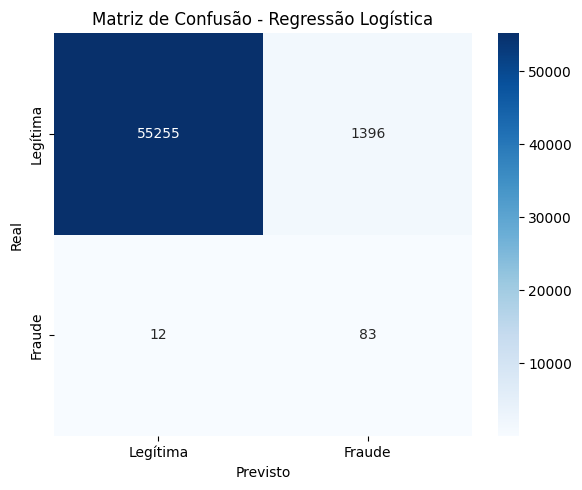

In [15]:
matriz_lr = confusion_matrix(y_test, pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítima', 'Fraude'], yticklabels=['Legítima', 'Fraude'])
plt.title('Matriz de Confusão - Regressão Logística')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

recall_lr = recall_score(y_test, pred_lr)
precisao_lr = precision_score(y_test, pred_lr)
f1_lr = f1_score(y_test, pred_lr)
roc_auc_lr = roc_auc_score(y_test, proba_lr)
pr_auc_lr = average_precision_score(y_test, proba_lr)

print(f"Recall: {recall_lr:.3f} | Precisão: {precisao_lr:.3f} | F1-score: {f1_lr:.3f}")
print(f"ROC-AUC: {roc_auc_lr:.3f} | PR-AUC: {pr_auc_lr:.3f}")

A Regressão Logística conseguiu identificar aproximadamente 87.4% das fraudes reais presentes no conjunto de teste (recall), o que é um resultado alto e desejável do ponto de vista de não deixar fraudes passarem despercebidas. Porém, a precisão ficou bastante baixa, em torno de 5.6%, o que significa que a grande maioria dos alertas de fraude gerados pelo modelo é, na verdade, de transações legítimas (falsos positivos). Isso ilustra bem o trade-off entre recall e precisão em problemas de fraude: um modelo muito sensível para capturar fraudes tende a gerar muitos alarmes falsos.



## 7. Modelo 2: Random Forest com balanceamento por peso de classe



In [ ]:
# Random Forest com class_weight='balanced' e max_samples reduzido, mantendo o tempo de
# treinamento viável mesmo em uma base com quase 227 mil transações de treino

modelo_rf = RandomForestClassifier(
    n_estimators=50, max_depth=10, class_weight='balanced',
    max_samples=0.3, random_state=42
)
modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)
proba_rf = modelo_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred_rf, target_names=['Legítima', 'Fraude']))

              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     56651
      Fraude       0.89      0.71      0.79        95

    accuracy                           1.00     56746
   macro avg       0.95      0.85      0.89     56746
weighted avg       1.00      1.00      1.00     56746



Recall: 0.705 | Precisão: 0.893 | F1-score: 0.788
ROC-AUC: 0.952 | PR-AUC: 0.780


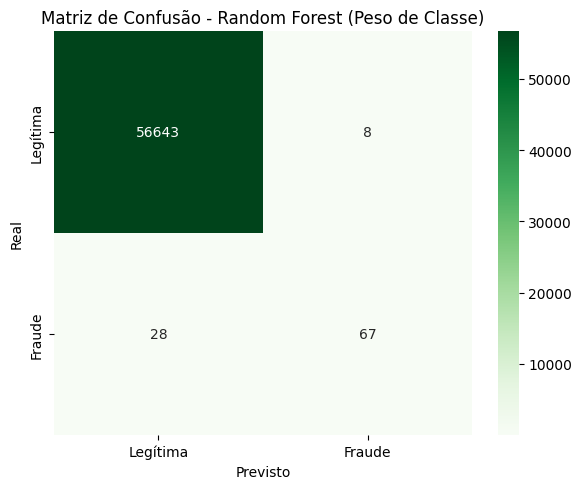

In [17]:
matriz_rf = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legítima', 'Fraude'], yticklabels=['Legítima', 'Fraude'])
plt.title('Matriz de Confusão - Random Forest (Peso de Classe)')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

recall_rf = recall_score(y_test, pred_rf)
precisao_rf = precision_score(y_test, pred_rf)
f1_rf = f1_score(y_test, pred_rf)
roc_auc_rf = roc_auc_score(y_test, proba_rf)
pr_auc_rf = average_precision_score(y_test, proba_rf)

print(f"Recall: {recall_rf:.3f} | Precisão: {precisao_rf:.3f} | F1-score: {f1_rf:.3f}")
print(f"ROC-AUC: {roc_auc_rf:.3f} | PR-AUC: {pr_auc_rf:.3f}")

O Random Forest inverteu o padrão observado na Regressão Logística: a precisão subiu para aproximadamente 89.3%, mas o recall caiu para cerca de 70.5%. Ou seja, quando esse modelo aponta uma fraude, ele acerta com muito mais frequência, mas deixa passar uma proporção maior de fraudes reais. O F1-score, que resume o equilíbrio entre as duas métricas, ficou em 0.788, superior ao da Regressão Logística.



## 8. Modelo 3: Random Forest com balanceamento por SMOTE

O SMOTE (Synthetic Minority Oversampling Technique) é uma técnica de balanceamento que cria exemplos sintéticos da classe minoritária, interpolando entre exemplos reais de fraude já existentes na base de treino, em vez de apenas duplicá-los. Isso ajuda o modelo a aprender uma fronteira de decisão mais generalizável para a classe rara, sem os riscos de overfitting que a simples duplicação de exemplos poderia causar.

Importante: o SMOTE foi aplicado apenas na base de treino, nunca na base de teste, para que a avaliação final do modelo reflita a distribuição real e desbalanceada de transações que ele encontraria em produção.



In [ ]:
# Aplicação do SMOTE apenas na base de treino, com sampling_strategy=0.05
# (as fraudes passam a representar 5% da base de treino, em vez dos ~0,17% originais;
# um balanceamento parcial, e não total, para manter o treinamento computacionalmente viável)

smote = SMOTE(random_state=42, sampling_strategy=0.05)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Distribuição de classes antes do SMOTE:")
print(y_train.value_counts())
print()
print("Distribuição de classes depois do SMOTE:")
print(y_train_smote.value_counts())

Distribuição de classes antes do SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

Distribuição de classes depois do SMOTE:
Class
0    226602
1     11330
Name: count, dtype: int64


In [19]:
modelo_rf_smote = RandomForestClassifier(
    n_estimators=50, max_depth=10, max_samples=0.3, random_state=42
)
modelo_rf_smote.fit(X_train_smote, y_train_smote)

pred_rf_smote = modelo_rf_smote.predict(X_test)
proba_rf_smote = modelo_rf_smote.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred_rf_smote, target_names=['Legítima', 'Fraude']))

              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     56651
      Fraude       0.89      0.78      0.83        95

    accuracy                           1.00     56746
   macro avg       0.95      0.89      0.92     56746
weighted avg       1.00      1.00      1.00     56746



Recall: 0.779 | Precisão: 0.892 | F1-score: 0.831
ROC-AUC: 0.976 | PR-AUC: 0.807


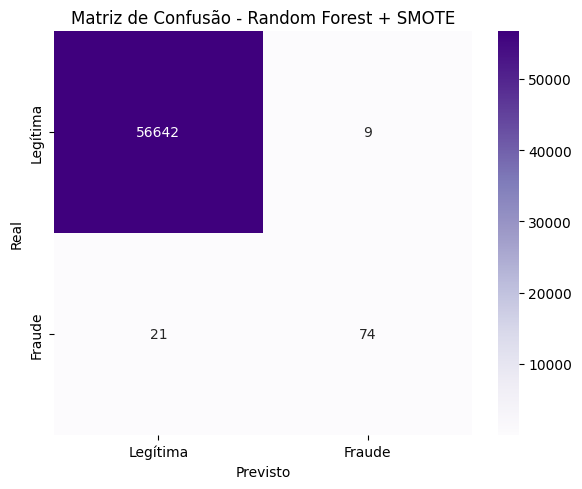

In [20]:
matriz_rf_smote = confusion_matrix(y_test, pred_rf_smote)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz_rf_smote, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Legítima', 'Fraude'], yticklabels=['Legítima', 'Fraude'])
plt.title('Matriz de Confusão - Random Forest + SMOTE')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

recall_smote = recall_score(y_test, pred_rf_smote)
precisao_smote = precision_score(y_test, pred_rf_smote)
f1_smote = f1_score(y_test, pred_rf_smote)
roc_auc_smote = roc_auc_score(y_test, proba_rf_smote)
pr_auc_smote = average_precision_score(y_test, proba_rf_smote)

print(f"Recall: {recall_smote:.3f} | Precisão: {precisao_smote:.3f} | F1-score: {f1_smote:.3f}")
print(f"ROC-AUC: {roc_auc_smote:.3f} | PR-AUC: {pr_auc_smote:.3f}")

O modelo com SMOTE trouxe o melhor equilíbrio entre os três testados: recall de aproximadamente 77.9%, precisão de 89.2% e F1-score de 0.831, superando tanto a Regressão Logística quanto o Random Forest sem balanceamento sintético. Isso sugere que oferecer ao modelo uma quantidade maior (ainda que sintética) de exemplos de fraude durante o treinamento ajudou a árvore a aprender fronteiras de decisão mais robustas para a classe minoritária, sem sacrificar tanto a precisão quanto ocorria no modelo baseado apenas em peso de classe.



## 9. Comparação final e seleção do modelo



In [21]:
tabela_comparativa = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Random Forest (peso de classe)', 'Random Forest + SMOTE'],
    'Recall': [recall_lr, recall_rf, recall_smote],
    'Precisão': [precisao_lr, precisao_rf, precisao_smote],
    'F1-score': [f1_lr, f1_rf, f1_smote],
    'ROC-AUC': [roc_auc_lr, roc_auc_rf, roc_auc_smote],
    'PR-AUC': [pr_auc_lr, pr_auc_rf, pr_auc_smote],
}).round(3)

tabela_comparativa

,Modelo,Recall,Precisão,F1-score,ROC-AUC,PR-AUC
0,Regressão Logística,0.874,0.056,0.105,0.966,0.672
1,Random Forest (peso de classe),0.705,0.893,0.788,0.952,0.780
2,Random Forest + SMOTE,0.779,0.892,0.831,0.976,0.807


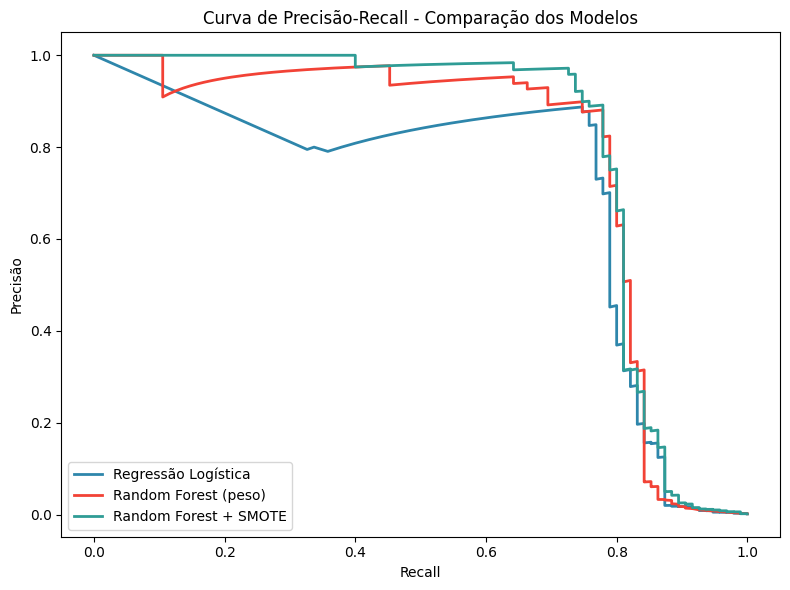

In [ ]:
# Curvas de precisão-recall dos três modelos, sobrepostas para facilitar a comparação visual

plt.figure(figsize=(8, 6))

for proba, nome, cor in [(proba_lr, 'Regressão Logística', '#2E86AB'),
                          (proba_rf, 'Random Forest (peso)', '#F24236'),
                          (proba_rf_smote, 'Random Forest + SMOTE', '#2F9C95')]:
    precisao_curva, recall_curva, _ = precision_recall_curve(y_test, proba)
    plt.plot(recall_curva, precisao_curva, label=nome, color=cor, linewidth=2)

plt.title('Curva de Precisão-Recall - Comparação dos Modelos')
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.legend()
plt.tight_layout()
plt.show()

A curva de precisão-recall confirma visualmente que o Random Forest com SMOTE mantém uma precisão mais alta em uma faixa maior de valores de recall, em comparação com os outros dois modelos, sendo a curva mais próxima do canto superior direito do gráfico (a região ideal). Por esse motivo, e considerando o equilíbrio apresentado na tabela comparativa, o **Random Forest com SMOTE** foi escolhido como modelo final deste projeto.



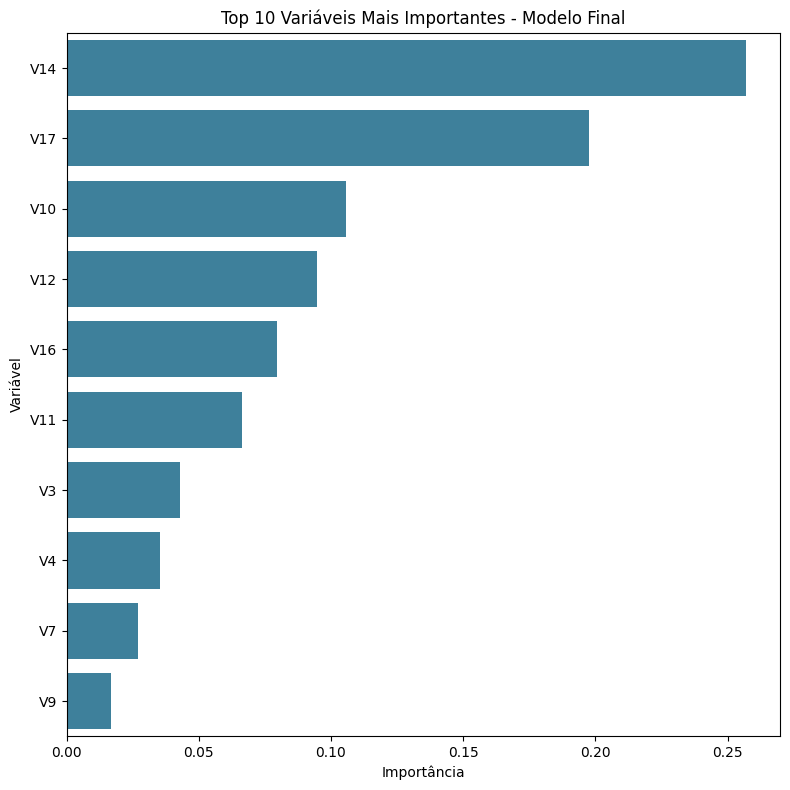

In [ ]:
# Importância das variáveis para o modelo final escolhido

importancias = pd.Series(modelo_rf_smote.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=importancias.head(10).values, y=importancias.head(10).index, color='#2E86AB')
plt.title('Top 10 Variáveis Mais Importantes - Modelo Final')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

As variáveis de maior importância para o modelo final coincidem, em boa parte, com aquelas que já haviam se destacado na análise de correlação da etapa exploratória, o que reforça a consistência entre a análise exploratória e o comportamento real do modelo treinado.



## 10. Comunicação dos resultados



Foram testados três modelos de classificação para detecção de fraude em transações de cartão de crédito, em uma base com desbalanceamento extremo (cerca de 0,17% de transações fraudulentas). O modelo final selecionado, um Random Forest treinado sobre uma base de treino balanceada parcialmente via SMOTE, foi capaz de identificar aproximadamente 77.9% das fraudes reais do conjunto de teste, com uma precisão de aproximadamente 89.2%, ou seja, a cada 10 alertas de fraude gerados pelo modelo, cerca de 9 correspondem, de fato, a fraudes reais.

A escolha entre os três modelos testados não é puramente técnica, e sim uma decisão de negócio sobre o apetite ao risco da instituição. Caso o custo de uma fraude não detectada seja considerado muito mais grave do que o incômodo de investigar um alerta falso, a Regressão Logística (com seu recall mais alto) pode ser preferível, mesmo com mais falsos positivos. Caso o custo operacional de investigar falsos alertas seja a maior preocupação, o Random Forest sem SMOTE oferece mais precisão. O modelo com SMOTE foi escolhido aqui por representar o melhor equilíbrio geral entre as duas métricas, mas a escolha final deveria ser validada junto à área de negócio responsável pela prevenção a fraudes.

Este projeto utilizou uma base já anonimizada por PCA, o que limita a interpretação de negócio de cada variável individualmente. Como próximos passos, seria recomendável: ajustar o limiar de decisão (threshold) do modelo para calibrar o trade-off entre recall e precisão de acordo com a capacidade operacional real da equipe de prevenção a fraudes; testar outros algoritmos como XGBoost e modelos de detecção de anomalias (não supervisionados), que costumam performar bem neste tipo de problema; e implementar um processo de monitoramento contínuo do modelo em produção, já que padrões de fraude tendem a evoluir ao longo do tempo, exigindo retreinamentos periódicos.